In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

In [7]:
df=pd.read_csv("HR-Employee-Attrition.csv")

In [9]:
# Display first 5 rows
df.head()

# Display last 5 rows
df.tail()

# Shape of dataset
df.shape

# Column names
df.columns

# Dataset information
df.info()

# Statistical summary
df.describe()

# Data types
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
# Check missing values
df.isnull().sum()

# Check duplicate records
df.duplicated().sum()

# Number of unique values
df.nunique()

# Check constant columns
df.nunique()[df.nunique()==1]

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

In [11]:
# Remove constant columns
df.drop(
    columns=[
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

# Verify updated shape
df.shape

(1470, 32)

# Step 6: Exploratory Data Analysis (EDA)

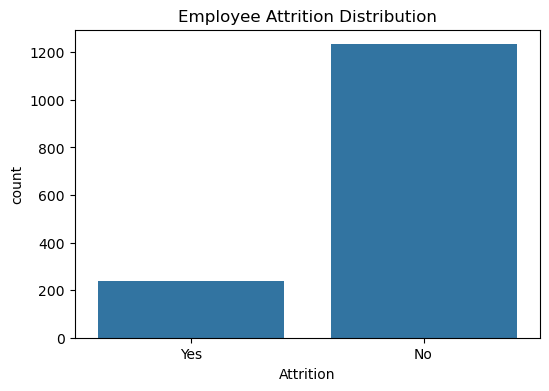

In [13]:
# Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.show()

### Insight:

The majority of employees are retained by the company, while a smaller proportion has left. This indicates that although the overall attrition rate is moderate, employee turnover remains an important HR concern.

### Business Recommendation:

Conduct regular employee engagement surveys and retention programs to identify concerns early and reduce unnecessary employee turnover.

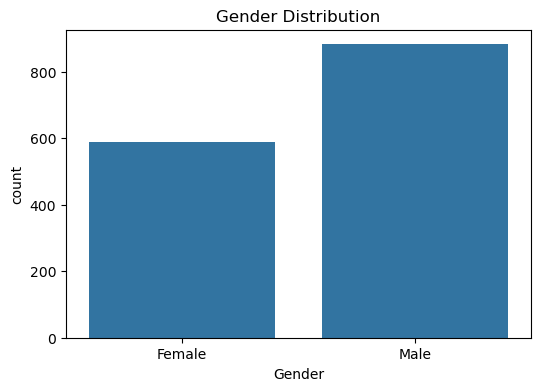

In [14]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

### Insight:

The workforce consists of both male and female employees, providing an overview of gender representation within the organization.

### Business Recommendation:

Continue promoting diversity and inclusion initiatives while ensuring equal opportunities for career growth and development.

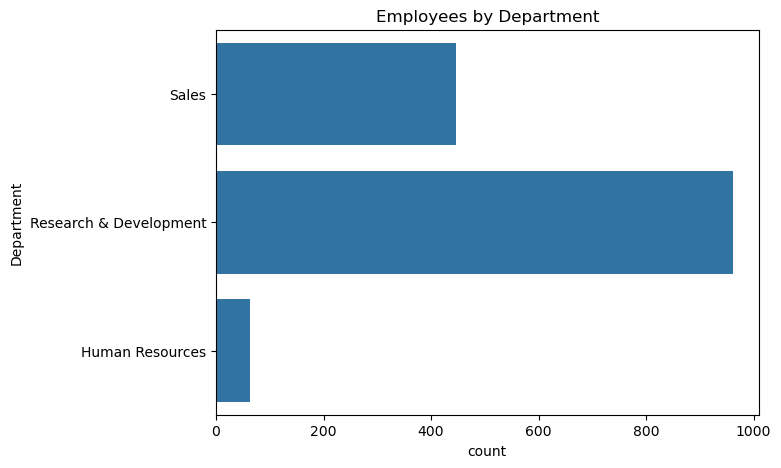

In [15]:
# Department Distribution
plt.figure(figsize=(7,5))
sns.countplot(y='Department', data=df)
plt.title('Employees by Department')
plt.show()

### Insight:

The Research & Development department has the highest number of employees, followed by Sales and Human Resources.

### Business Recommendation:

Allocate HR resources and employee engagement initiatives proportionally, with greater focus on larger departments where workforce management has a bigger impact.

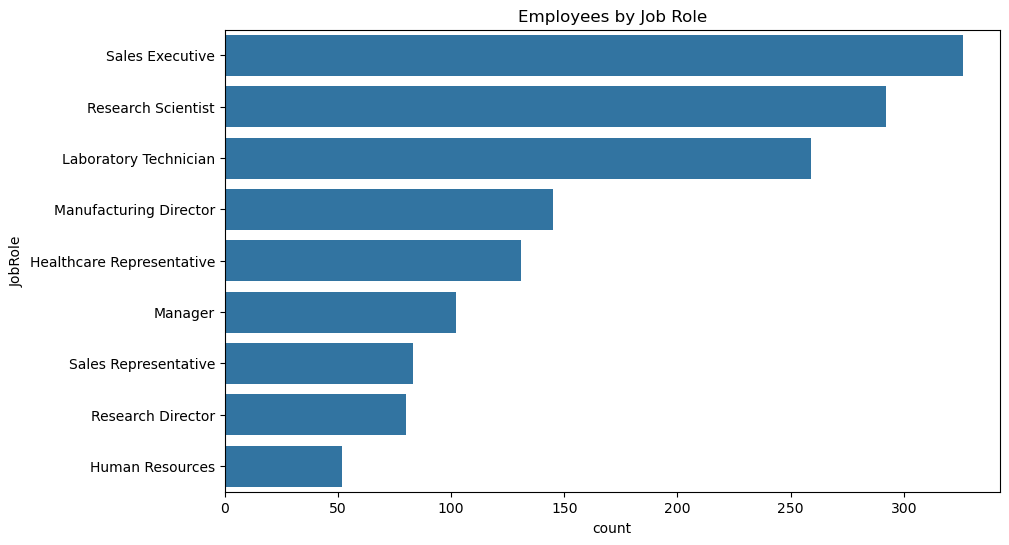

In [16]:
# Job Role Distribution
plt.figure(figsize=(10,6))
sns.countplot(y='JobRole', data=df)
plt.title('Employees by Job Role')
plt.show()

### Insight:

Some job roles have significantly more employees than others, indicating that business operations rely heavily on specific roles.

### Business Recommendation:

Provide targeted training and career development opportunities for high-volume job roles to improve productivity and employee retention.

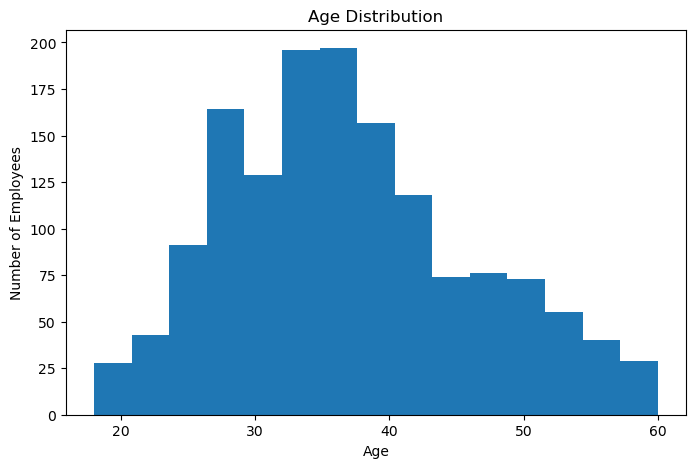

In [17]:
# Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=15)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

### Insight:

Most employees belong to the 26–35 age group, indicating a relatively young workforce.

### Business Recommendation:

Design career progression plans and leadership development programs to retain employees during the early and middle stages of their careers.

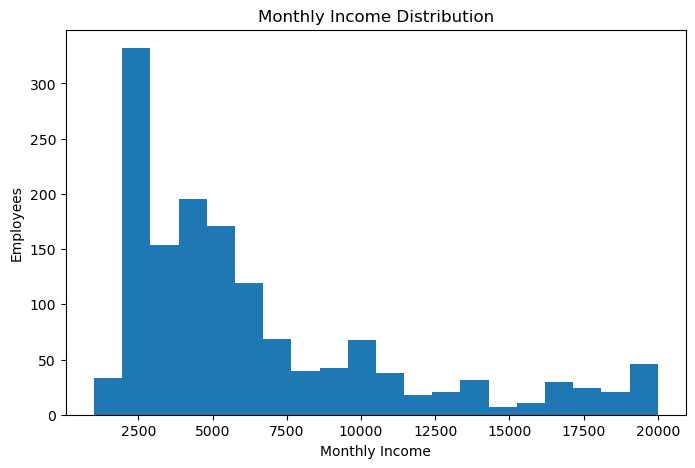

In [18]:
# Monthly Income Distribution
plt.figure(figsize=(8,5))
plt.hist(df['MonthlyIncome'], bins=20)
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Employees')
plt.show()

### Insight:

Most employees fall within the lower to middle income range, while comparatively fewer employees earn higher salaries.

### Business Recommendation:

Regularly review compensation policies to ensure salaries remain competitive and aligned with industry standards.

# Step 7: Attrition Analysis

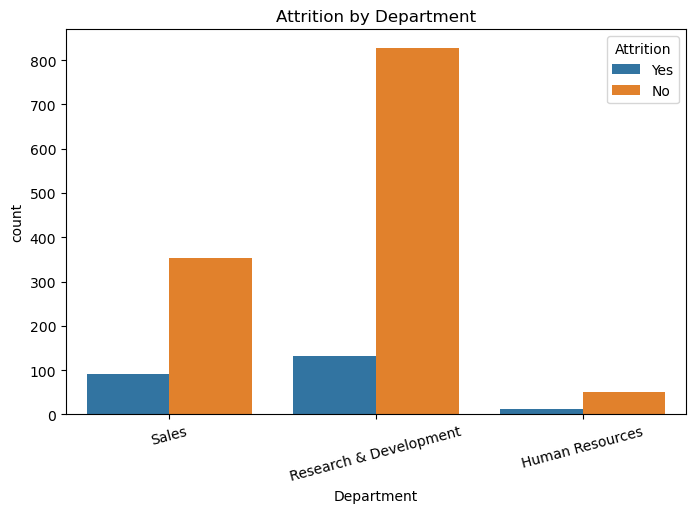

In [19]:
# Attrition by Department
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Attrition by Department')
plt.xticks(rotation=15)
plt.show()

### Insight:

Attrition is not evenly distributed across departments. Some departments experience noticeably higher employee turnover.

### Business Recommendation:

Investigate workload, management practices, and employee satisfaction within high-attrition departments to improve retention.

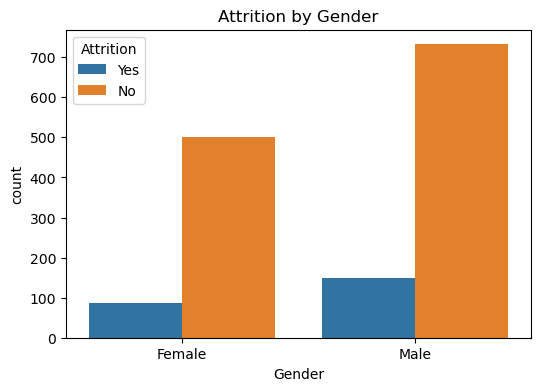

In [20]:
# Attrition by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title('Attrition by Gender')
plt.show()

### Insight:

Employee attrition occurs across both genders. Compare the proportions rather than only the counts to determine whether one group is disproportionately affected.

### Business Recommendation:

Ensure HR policies, employee benefits, and career development opportunities are equitable for all employees.

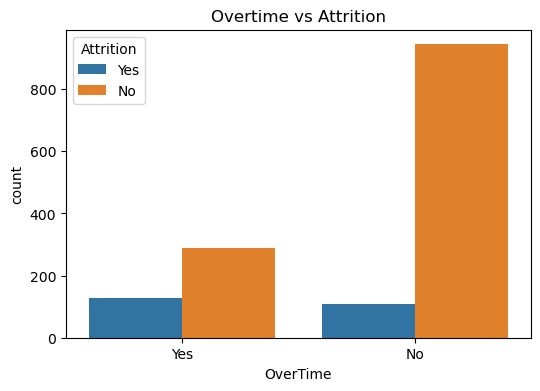

In [21]:
# Attrition by Overtime
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Overtime vs Attrition')
plt.show()

### Insight:

Employees working overtime tend to leave the organization more frequently than those who do not work overtime.

### Business Recommendation:

Monitor overtime hours carefully and encourage healthy work-life balance to reduce employee burnout and improve retention.

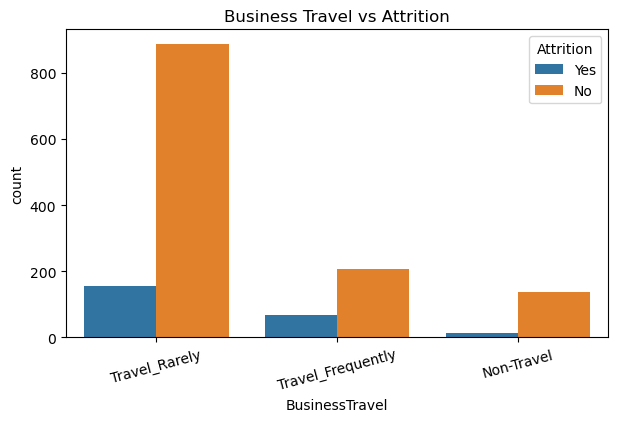

In [22]:
# Attrition by Business Travel
plt.figure(figsize=(7,4))
sns.countplot(x='BusinessTravel', hue='Attrition', data=df)
plt.title('Business Travel vs Attrition')
plt.xticks(rotation=15)
plt.show()

### Insight:

Employees who travel frequently may exhibit higher attrition compared to employees who travel rarely or not at all.

### Business Recommendation:

Review travel policies, provide additional support for frequent travelers, and consider flexible work arrangements where possible.

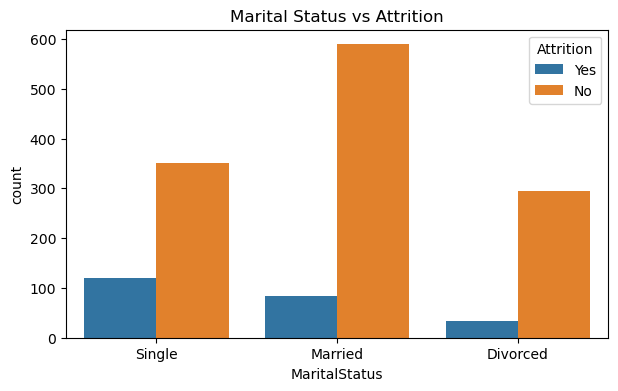

In [23]:
# Attrition by Marital Status
plt.figure(figsize=(7,4))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title('Marital Status vs Attrition')
plt.show()

### Insight:

Attrition varies across different marital status groups, indicating that personal circumstances may influence employee retention.

### Business Recommendation:

Offer flexible work arrangements and employee wellness programs to accommodate diverse personal needs.

# Step 8: Numerical Analysis

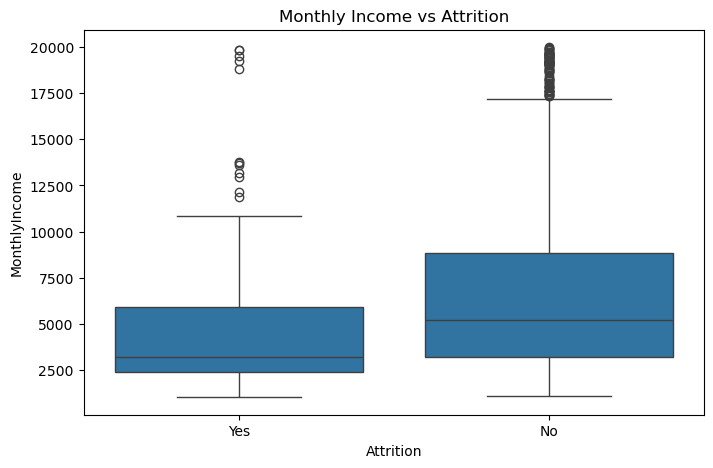

In [24]:
# Salary vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

### Insight:

Employees with lower salaries generally appear more likely to leave than those receiving higher compensation.

### Business Recommendation:

Review salary structures and introduce performance-based incentives to improve employee retention.

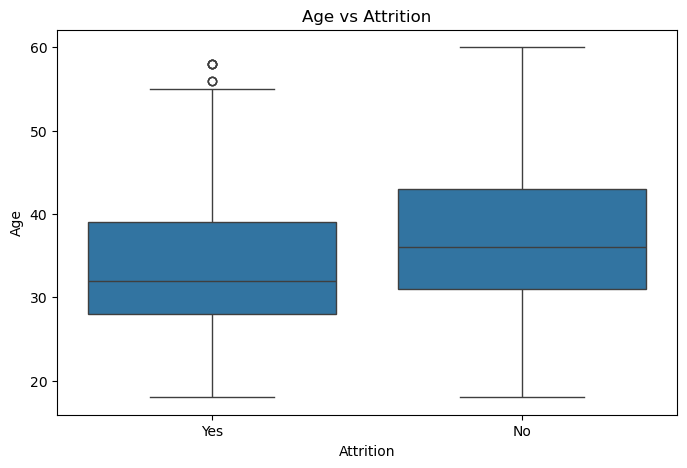

In [25]:
# Age vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

### Insight:

Employees who leave the organization are generally younger compared to long-term employees.

### Business Recommendation:

Strengthen onboarding, mentoring, and career development programs for early-career employees.

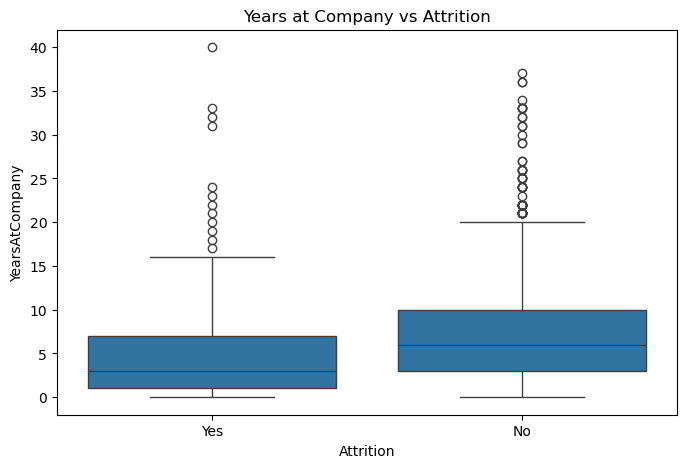

In [26]:
# Years at Company vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company vs Attrition')
plt.show()

### Insight:

Employees with fewer years at the company appear more likely to leave, suggesting higher turnover among newer employees.

### Business Recommendation:

Enhance onboarding experiences and implement retention initiatives during the first few years of employment.

# Step 9: Correlation Analysis

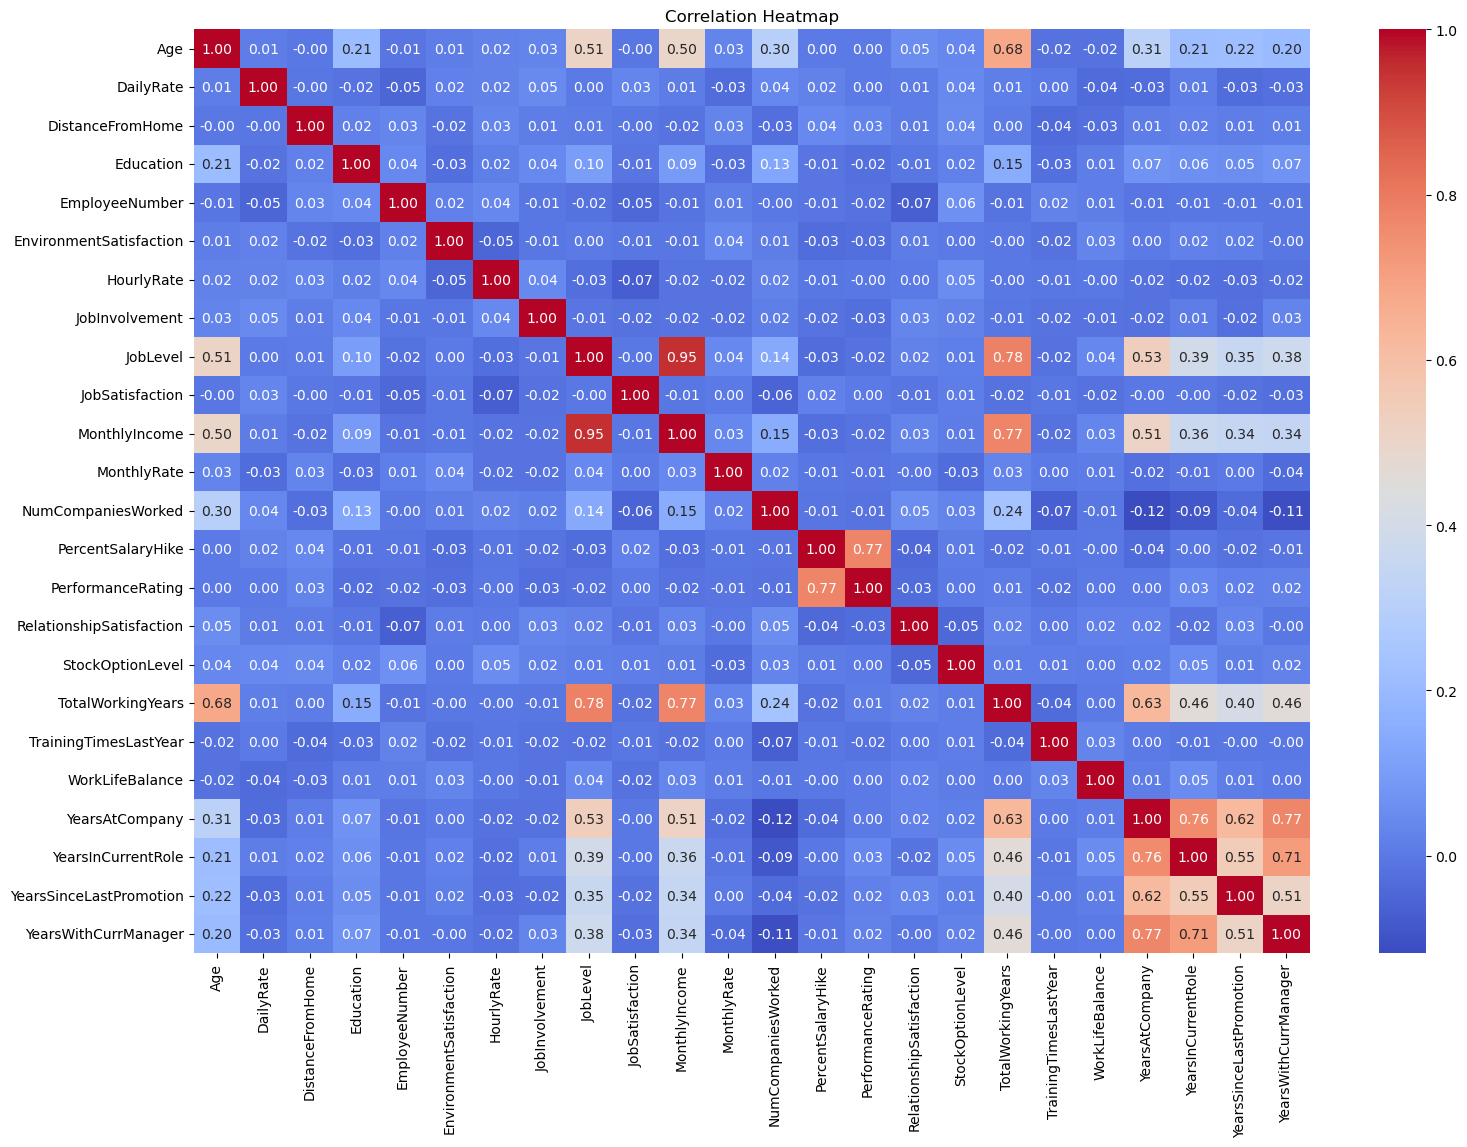

In [27]:
plt.figure(figsize=(18,12))
sns.heatmap(df.select_dtypes(include=['int64']).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Insight:

The correlation analysis shows relationships among numerical variables. Most variables have weak to moderate correlations, indicating that employee attrition is influenced by multiple factors rather than a single metric.

### Business Recommendation:

Develop retention strategies based on a combination of factors such as salary, work-life balance, job satisfaction, and career growth instead of relying on one indicator.

# Step 10: Key Business Insights

In [29]:
# Employees by Department
df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [30]:
# Attrition Count
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [31]:
# Job Role Distribution
df['JobRole'].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [32]:
# Overtime Distribution
df['OverTime'].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

In [33]:
# Average Monthly Income
df['MonthlyIncome'].mean()

np.float64(6502.931292517007)

In [34]:
# Average Age
df['Age'].mean()

np.float64(36.923809523809524)

In [35]:
# Average Years at Company
df['YearsAtCompany'].mean()

np.float64(7.0081632653061225)